<a href="https://colab.research.google.com/github/syedtwasti/Automated-Geospatial-Pipeline-for-Multi-Temporal-Environmental-Analysis-Islamabad-OEL-/blob/main/Automated%20Geospatial%20Pipeline%20for%20Multi-Temporal%20Environmental%20Analysis%20(Islamabad).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT: Islamabad Environmental Monitoring Pipeline

# PHASE 1 — SETUP & ENVIRONMENT

In [1]:
!pip install rasterio geopandas rasterstats shapely fiona pyproj matplotlib # Install necessary Python libraries for geospatial data processing and visualization.

In [2]:
from google.colab import drive
drive.mount('/content/drive') # Mount Google Drive to access files stored there.

Mounted at /content/drive


In [3]:
import os

BASE = "/content/drive/MyDrive/gis_oel/" # Define the base directory for the project in Google Drive.

DATA1 = os.path.join(BASE, "data/indices_date1/") # Path to raster data for the first date.
DATA2 = os.path.join(BASE, "data/indices_date2/") # Path to raster data for the second date.
SHAPE = os.path.join(BASE, "data/shapefile/islamabad_shapefile.shp") # Path to the study area shapefile.

OUTPUT = os.path.join(BASE, "outputs/") # Define the output directory for processed files.
os.makedirs(OUTPUT, exist_ok=True) # Create the output directory if it doesn't already exist.

# PHASE 2 — IMPORT LIBRARIES

In [4]:
import rasterio # Library for reading and writing raster datasets.
import geopandas as gpd # Library for working with geospatial vector data (GeoDataFrames).
import numpy as np # Numerical computing library, especially for array operations.
import matplotlib.pyplot as plt # Plotting library for creating visualizations.
from rasterstats import zonal_stats # Library for computing statistics of raster data within vector geometries.

# PHASE 3 — CORE UTILITY FUNCTIONS

In [5]:
def load_raster(path):
    src = rasterio.open(path) # Open the raster file using rasterio.
    arr = src.read(1).astype(float) # Read the first band of the raster as a float array.

    # Handle NoData values, replacing them with NaN for correct calculations.
    arr[arr == 0] = np.nan

    return arr, src # Return the raster array and its source metadata.

Save raster function

In [6]:
def save_raster(array, ref_src, out_path):
    meta = ref_src.meta.copy() # Copy metadata from a reference raster for the new raster.
    meta.update(dtype=rasterio.float32) # Update the data type to float32 for consistency.

    with rasterio.open(out_path, "w", **meta) as dst: # Open a new raster file for writing with updated metadata.
        dst.write(array.astype(rasterio.float32), 1) # Write the provided array as the first band to the new raster.

Zonal stats function

In [7]:
def compute_zonal_stats(gdf, raster_path, col_name):
    # Compute zonal statistics (mean) for each polygon in the GeoDataFrame using the specified raster.
    stats = zonal_stats(gdf, raster_path, stats=["mean"], nodata=np.nan)
    # Extract the mean values and assign them to a new column in the GeoDataFrame.
    gdf[col_name] = [s["mean"] for s in stats]
    return gdf # Return the GeoDataFrame with the new zonal statistics column.

# 🗺️ PHASE 4 — LOAD SHAPEFILE & ALIGN CRS

In [9]:
import glob # Module for finding pathnames matching a specified pattern.

def find_raster(folder, keyword):
    files = glob.glob(os.path.join(folder, "*.tif")) # List all .tif files in the given folder.

    for f in files:
        if keyword in f: # Check if the specified keyword is present in the filename.
            return f # Return the full path of the found raster file.

    raise FileNotFoundError(f"{keyword} not found in {folder}") # Raise an error if no matching file is found.

In [10]:
ndvi_path = find_raster(DATA1, "NDVI") # Find the NDVI raster file for the first date.
print("NDVI file:", ndvi_path) # Print the path to confirm the file has been located.

NDVI file: /content/drive/MyDrive/gis_oel/data/indices_date1/HLSS30_VI.020_NDVI_doy2024185_aid0001_43N.tif


# 🌿 PHASE 5


In [15]:
print("NDVI recomputation skipped — using precomputed indices from AppEEARS") # Inform the user that NDVI calculation is skipped as precomputed data is used.

NDVI recomputation skipped — using precomputed indices from AppEEARS


# 📊 PHASE 6 — PROCESSING ALL INDICES (July '24)

In [19]:
indices = ["NDVI", "NDWI", "EVI", "SAVI"] # Define a list of vegetation/water indices to process.

# Loop through each index to compute zonal statistics for the first date.
for idx in indices:
    path = find_raster(DATA1, idx) # Find the raster file for the current index for DATA1.
    # Note: `gdf` is expected to be loaded from the shapefile before this cell is executed.
    gdf = compute_zonal_stats(gdf, path, f"{idx}_1") # Compute mean zonal statistics and add as a new column (e.g., NDVI_1).

In [20]:
def find_raster_by_date(folder, keyword, doy):
    files = glob.glob(os.path.join(folder, "*.tif")) # List all .tif files in the specified folder.

    for f in files:
        # Check if the keyword and specific day of year (doy) are present in the filename.
        if keyword in f and f"doy{doy}" in f:
            return f # Return the full path of the found raster file.

    raise FileNotFoundError(f"{keyword} with doy{doy} not found") # Raise an error if no matching file is found.

# 📊 PHASE 7 — PROCESS ALL INDICES (July '25)

In [17]:
# Loop through each index to compute zonal statistics for the second date.
for idx in indices:
    path = find_raster(DATA2, idx) # Find the raster file for the current index for DATA2.
    # `gdf` is assumed to have been populated with data from previous steps.
    gdf = compute_zonal_stats(gdf, path, f"{idx}_2") # Compute mean zonal statistics and add as a new column (e.g., NDVI_2).

In [18]:
def find_raster_by_date(folder, keyword, doy):
    files = glob.glob(os.path.join(folder, "*.tif")) # List all .tif files in the specified folder.

    for f in files:
        # Check if the keyword and specific day of year (doy) are present in the filename.
        if keyword in f and f"doy{doy}" in f:
            return f # Return the full path of the found raster file.

    raise FileNotFoundError(f"{keyword} with doy{doy} not found") # Raise an error if no matching file is found.

# 📉 PHASE 8 — CHANGE DETECTION

In [22]:
# Calculate the change for each index by subtracting values from date 1 from date 2.
for idx in indices:
    gdf[f"{idx}_change"] = gdf[f"{idx}_2"] - gdf[f"{idx}_1"]

print("Change detection complete") # Confirm that the change detection process has finished.

Change detection complete


In [30]:
ndvi1, src = load_raster(find_raster(DATA1, "NDVI")) # Load the NDVI raster for the first date.
ndvi2, _ = load_raster(find_raster(DATA2, "NDVI")) # Load the NDVI raster for the second date.

ndvi_change = ndvi2 - ndvi1 # Calculate the pixel-wise difference between the two NDVI rasters.

save_raster(ndvi_change, src, os.path.join(OUTPUT, "NDVI_change.tif")) # Save the resulting NDVI change raster to the output directory.

print("NDVI_change.tif created") # Confirm the creation of the NDVI change raster file.

NDVI_change.tif created


# 💾 PHASE 9 — SAVE FINAL VECTOR OUTPUT

In [23]:
out_vector = os.path.join(OUTPUT, "islamabad_analysis.geojson") # Define the full path for the output GeoJSON file.
gdf.to_file(out_vector, driver="GeoJSON") # Save the GeoDataFrame containing all analysis results to a GeoJSON file.

print("Saved:", out_vector) # Print the path where the GeoJSON file was saved.

Saved: /content/drive/MyDrive/gis_oel/outputs/islamabad_analysis.geojson


In [31]:
gdf.to_file("islamabad_analysis.geojson", driver="GeoJSON") # Save the GeoDataFrame to a GeoJSON file in the current working directory. This is redundant if the previous cell already saved it to the `OUTPUT` path.

# PHASE 10 — VISUALIZATION (ANALYTICAL MAPS)

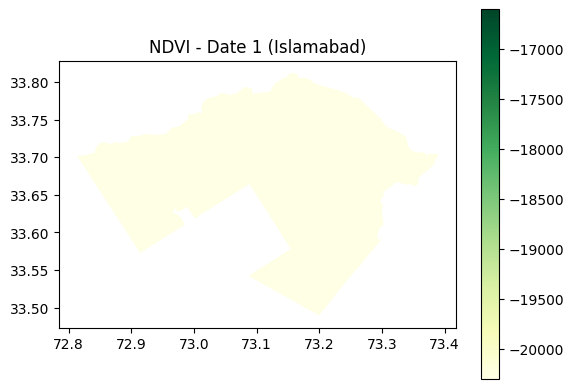

In [36]:
gdf.plot(column="NDVI_1", cmap="YlGn", legend=True) # Plot the GeoDataFrame, color-coding polygons based on 'NDVI_1' values.
plt.title("NDVI - Date 1 (Islamabad)") # Set the title of the plot.
plt.show() # Display the generated plot.

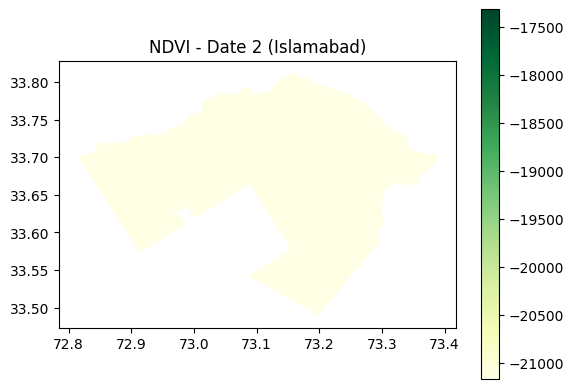

In [38]:
gdf.plot(column="NDVI_2", cmap="YlGn", legend=True) # Plot the GeoDataFrame, color-coding polygons based on 'NDVI_1' values.
plt.title("NDVI - Date 2 (Islamabad)") # Set the title of the plot.
plt.show() # Display the generated plot.

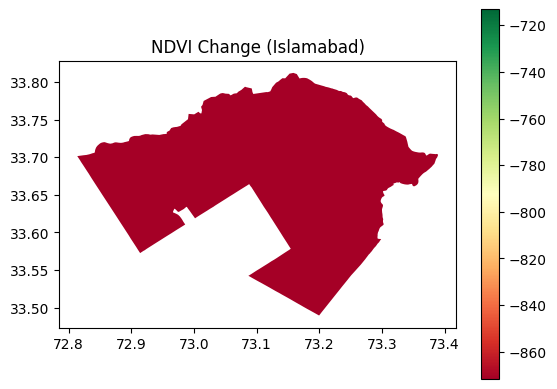

In [25]:
gdf.plot(column="NDVI_change", cmap="RdYlGn", legend=True) # Plot the GeoDataFrame, color-coding polygons based on 'NDVI_change' values.
plt.title("NDVI Change (Islamabad)") # Set the title of the plot.
plt.show() # Display the generated plot.

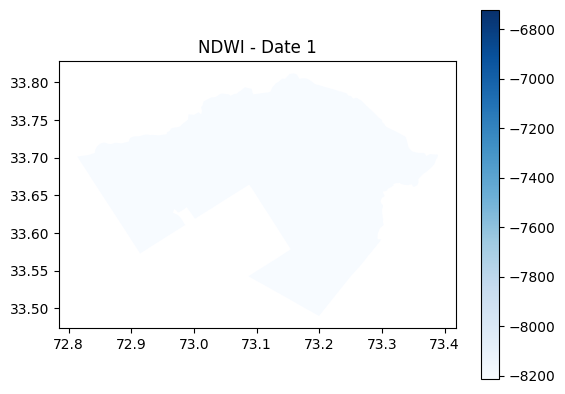

In [26]:
gdf.plot(column="NDWI_1", cmap="Blues", legend=True) # Plot the GeoDataFrame, color-coding polygons based on 'NDWI_1' values.
plt.title("NDWI - Date 1") # Set the title of the plot.
plt.show() # Display the generated plot.

# 📊 PHASE 11 — EXPORTING MAPS AS IMAGES

Saved map: /content/drive/MyDrive/gis_oel/outputs/ndvi_change.png


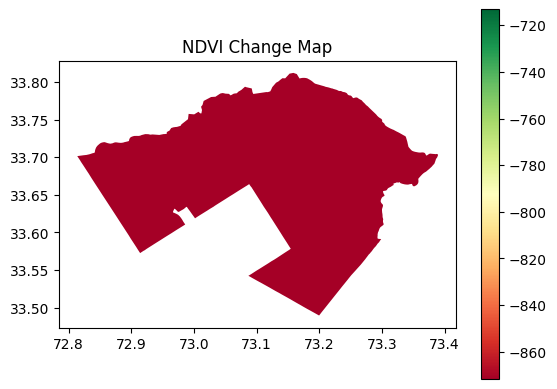

In [27]:
fig, ax = plt.subplots() # Create a new figure and a set of subplots.
gdf.plot(column="NDVI_change", cmap="RdYlGn", legend=True, ax=ax) # Plot the NDVI change on the created axes.
plt.title("NDVI Change Map") # Set the title of the map.

img_path = os.path.join(OUTPUT, "ndvi_change.png") # Define the output path for saving the map image.
plt.savefig(img_path) # Save the current plot as a PNG image file.

print("Saved map:", img_path) # Confirm that the map image has been saved and display its path.

In [32]:
plt.savefig(os.path.join(OUTPUT, "ndvi_change_map.png")) # Save the most recently generated plot to a file, potentially overwriting or creating a duplicate if run directly after the previous cell.

<Figure size 640x480 with 0 Axes>

# SUMMARY STATS

In [28]:
print("Summary Statistics:\n") # Print a header for the summary statistics output.
print(gdf.describe()) # Print descriptive statistics (count, mean, std, min, max, quartiles) for all numerical columns in the GeoDataFrame.

Summary Statistics:

       Shape_Leng  Shape_Area                 date              validOn  \
count     1.00000    1.000000                    1                    1   
mean      1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
min       1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
25%       1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
50%       1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
75%       1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
max       1.74531    0.087645  2022-09-02 00:00:00  2022-09-09 00:00:00   
std           NaN         NaN                  NaN                  NaN   

      validTo        NDVI_1       NDWI_1      EVI_1        SAVI_1  \
count       0      1.000000     1.000000     1.0000      1.000000   
mean      NaT -18451.389792 -7469.069602 -1439.9297 -18552.193784   
min       NaT -18451.389792 -7469.069602 -1439.9297 -18552.193784   
25%       NaT -18451.389792

In [29]:
reqs = """rasterio
geopandas
rasterstats
numpy
matplotlib
shapely
fiona
pyproj
""" # Define a multi-line string containing all required Python packages for this project.

with open(os.path.join(BASE, "requirements.txt"), "w") as f: # Open a file named 'requirements.txt' in write mode within the base directory.
    f.write(reqs) # Write the string of package requirements to the 'requirements.txt' file.

print("requirements.txt created") # Confirm the successful creation of the requirements file.

requirements.txt created


In [35]:
print(gdf.columns)

Index(['Shape_Leng', 'Shape_Area', 'ADM2_EN', 'ADM2_PCODE', 'ADM2_REF',
       'ADM2ALT1EN', 'ADM2ALT2EN', 'ADM1_EN', 'ADM1_PCODE', 'ADM0_EN',
       'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry', 'NDVI_1',
       'NDWI_1', 'EVI_1', 'SAVI_1', 'NDVI_2', 'NDWI_2', 'EVI_2', 'SAVI_2',
       'NDVI_change', 'NDWI_change', 'EVI_change', 'SAVI_change'],
      dtype='object')


In [39]:
import matplotlib.pyplot as plt

def plot_map(gdf, column, title, cmap):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    gdf.plot(
        column=column,
        cmap=cmap,
        legend=True,
        ax=ax,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_title(title, fontsize=14)
    ax.axis("off")

    plt.show()

# MAP 1 — NDVI SPATIAL DISTRIBUTION

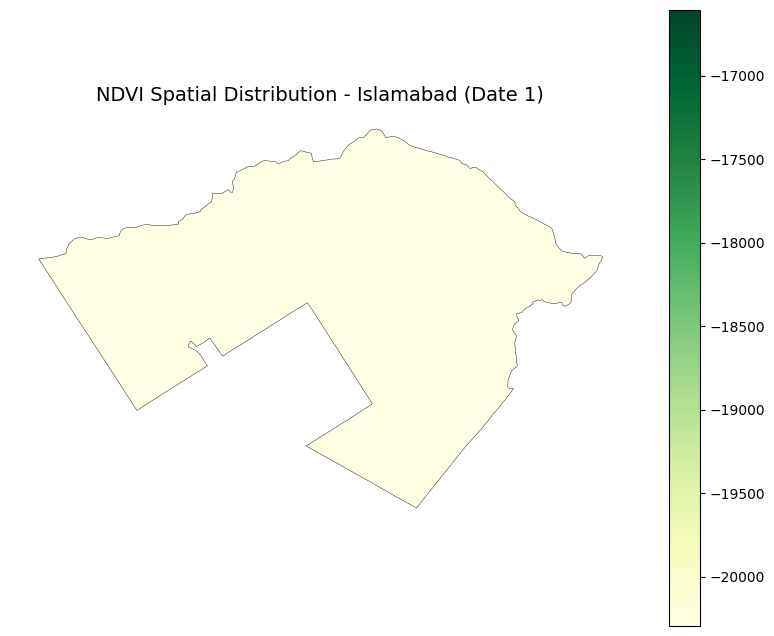

In [40]:
plot_map(
    gdf,
    "NDVI_1",
    "NDVI Spatial Distribution - Islamabad (Date 1)",
    "YlGn"
)

# MAP 2 — NDWI SPATIAL DISTRIBUTION

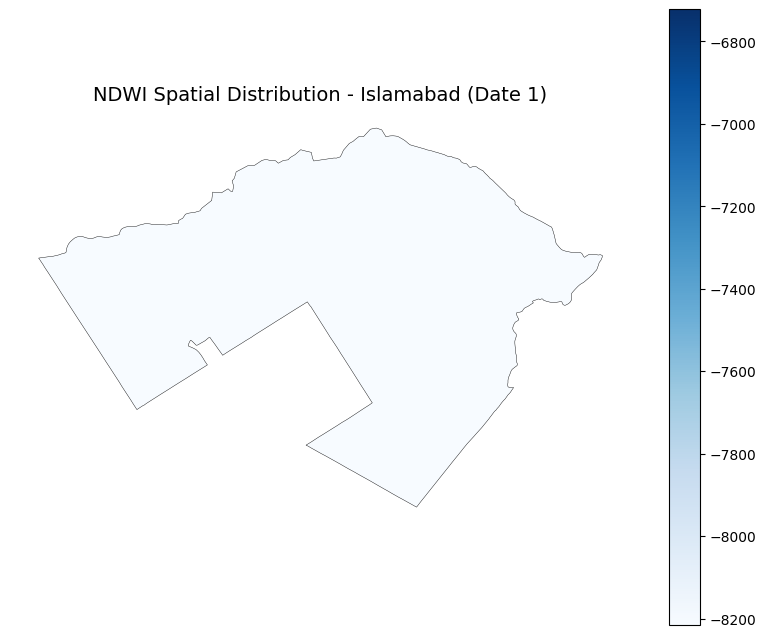

In [41]:
plot_map(
    gdf,
    "NDWI_1",
    "NDWI Spatial Distribution - Islamabad (Date 1)",
    "Blues"
)

In [42]:
gdf["NDVI_change"] = gdf["NDVI_2"] - gdf["NDVI_1"]

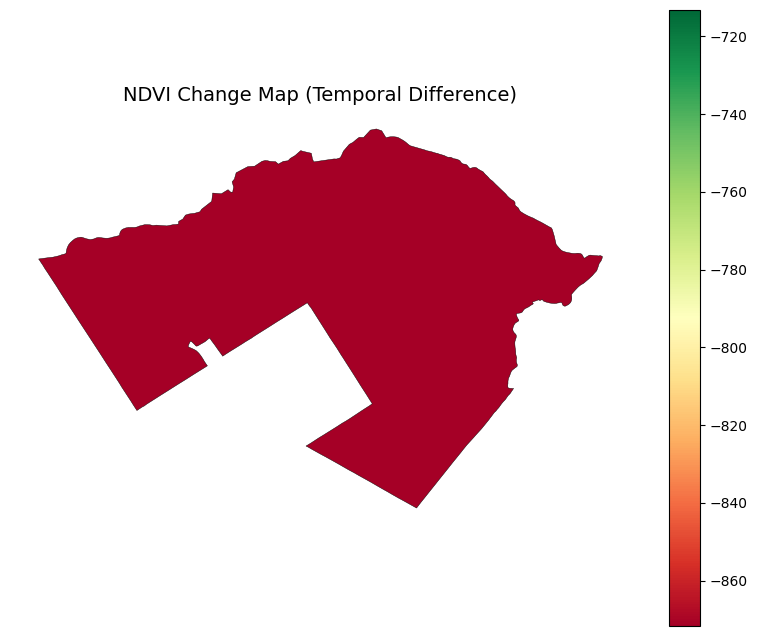

In [43]:
plot_map(
    gdf,
    "NDVI_change",
    "NDVI Change Map (Temporal Difference)",
    "RdYlGn"
)

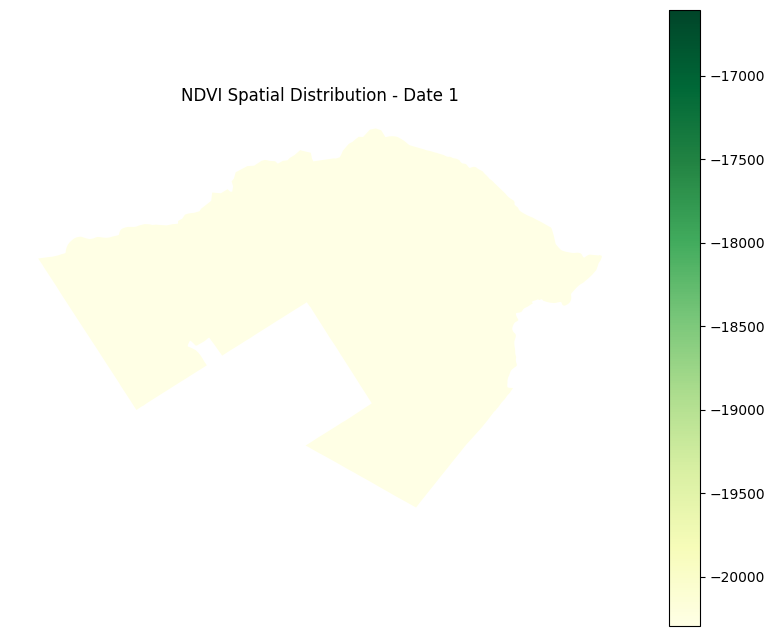

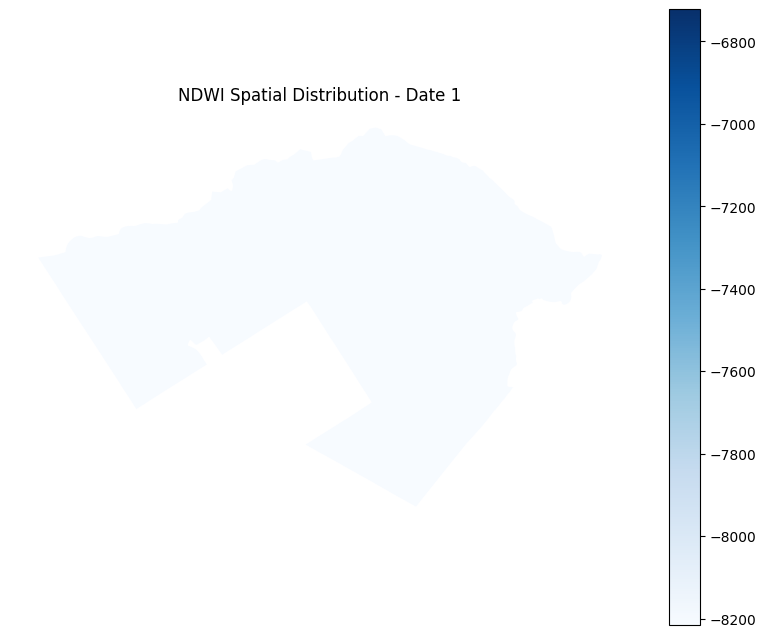

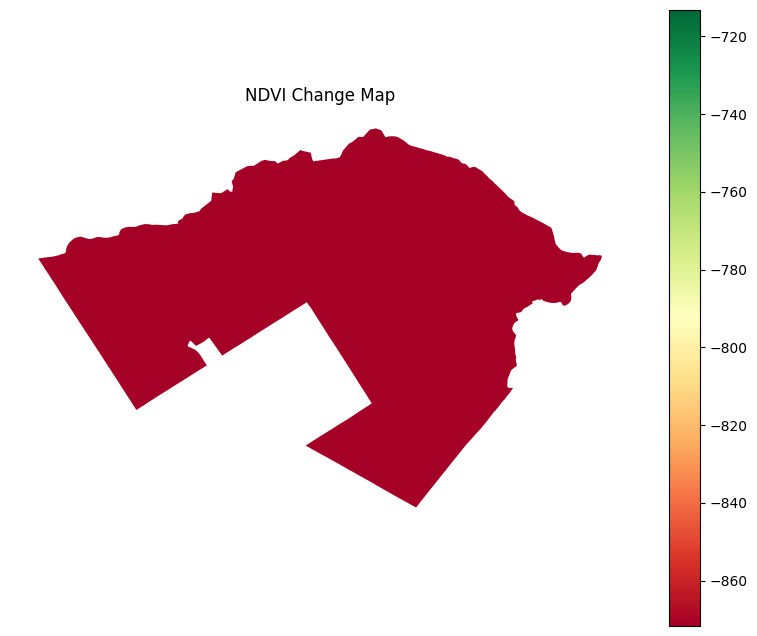

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column="NDVI_1", cmap="YlGn", legend=True, ax=ax)
ax.set_title("NDVI Spatial Distribution - Date 1")
ax.axis("off")

plt.savefig("/content/drive/MyDrive/gis_oel/outputs/ndvi_map.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column="NDWI_1", cmap="Blues", legend=True, ax=ax)
ax.set_title("NDWI Spatial Distribution - Date 1")
ax.axis("off")

plt.savefig("/content/drive/MyDrive/gis_oel/outputs/ndwi_map.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column="NDVI_change", cmap="RdYlGn", legend=True, ax=ax)
ax.set_title("NDVI Change Map")
ax.axis("off")

plt.savefig("/content/drive/MyDrive/gis_oel/outputs/ndvi_change_map.png", dpi=300)